# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research question

Can historical search-performance signals identify content pages that are likely to experience a meaningful decline in search impressions over the next 30 days, so that reviewers can prioritize which pages to inspect first?

### Decision supported

The output is a ranked review queue. It is intended to help a reviewer decide which pages deserve attention first; it does not claim that refreshing a page will cause recovery.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This study uses the FlyRank pseudonymized warehouse release `flyrank_pseudonymized_warehouse_release_v20260703`, hosted on Hugging Face.

The main table is `fact_content_daily_performance`, at report_date × client × content grain. I use `dim_content` for safe content metadata and `dim_clients` to check client history coverage.

The daily release covers 2025-01-27 through 2026-06-30. I construct historical features from a 90-day window before the decision point and define the outcome from the following 30-day window.

I exclude client names, domains, URLs, private queries, credentials, and raw text. I also exclude identifier columns such as `client_hash_id` and `content_hash_id` from model features. Target-derived fields such as `trend_direction` and `trend_pct` are not used as features because they can leak the outcome.

In [40]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

In [41]:
import os
import getpass

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass(
        "Paste your Hugging Face READ token (hf_...): "
    )

print("Hugging Face token loaded:", bool(HF_TOKEN))

Hugging Face token loaded: True


In [42]:
import duckdb

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    print(name, con.sql(f"SELECT COUNT(*) AS rows FROM {src}").df())

dim_clients    rows
0   104
dim_content      rows
0  519606


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily        rows
0  78835655
fact_query_90d       rows
0  2414248


In [43]:
bounds = con.sql(f"""
    SELECT
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS contents
    FROM {TABLES['fact_daily']}
""").df()

bounds

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,clients,contents
0,2025-01-27,2026-06-30,70,427292


In [44]:
clients = con.sql(f"""
    SELECT
        client_hash_id,
        access_profile,
        gsc_data_start,
        ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

display(clients.head(10))

,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [45]:
FEATURE_START = "2026-03-03"
FEATURE_END = "2026-05-31"

REFERENCE_START = "2026-05-02"
REFERENCE_END = "2026-05-31"

TARGET_START = "2026-06-01"
TARGET_END = "2026-06-30"

query = f"""
WITH aggregated AS (
    SELECT
        client_hash_id,
        content_hash_id,

        -- Full 90-day historical feature window
        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_90d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                THEN gsc_clicks
                ELSE 0
            END
        ) AS clicks_90d,

        AVG(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                 AND gsc_impressions > 0
                THEN gsc_avg_position
            END
        ) AS avg_position_90d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                THEN ga4_sessions
                ELSE 0
            END
        ) AS sessions_90d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                THEN ga4_engaged_sessions
                ELSE 0
            END
        ) AS engaged_sessions_90d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                THEN ga4_pageviews
                ELSE 0
            END
        ) AS pageviews_90d,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                THEN scroll_events
                ELSE 0
            END
        ) AS scroll_events_90d,

        COUNT(
            CASE
                WHEN report_date BETWEEN DATE '{FEATURE_START}'
                                     AND DATE '{FEATURE_END}'
                 AND gsc_impressions > 0
                THEN 1
            END
        ) AS active_search_days,

        -- 30-day reference period
        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{REFERENCE_START}'
                                     AND DATE '{REFERENCE_END}'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_reference_30d,

        -- Future 30-day target period
        SUM(
            CASE
                WHEN report_date BETWEEN DATE '{TARGET_START}'
                                     AND DATE '{TARGET_END}'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_future_30d

    FROM {TABLES["fact_daily"]}

    WHERE report_date BETWEEN DATE '{FEATURE_START}'
                          AND DATE '{TARGET_END}'

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    *,
    100.0 * clicks_90d / NULLIF(impressions_90d, 0) AS ctr_90d,

    CASE
        WHEN impressions_future_30d <
             0.80 * impressions_reference_30d
        THEN 1
        ELSE 0
    END AS future_decline

FROM aggregated

WHERE impressions_90d >= 100
  AND impressions_reference_30d > 0
"""

print("Query ready.")

Query ready.


In [46]:
capstone_data = con.sql(query).df()

print("Rows:", len(capstone_data))
print("Columns:", len(capstone_data.columns))
print(
    "Future decline rate:",
    round(capstone_data["future_decline"].mean(), 4)
)

display(capstone_data.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 148118
Columns: 14
Future decline rate: 0.661


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,avg_position_90d,sessions_90d,engaged_sessions_90d,pageviews_90d,scroll_events_90d,active_search_days,impressions_reference_30d,impressions_future_30d,ctr_90d,future_decline
0,client_65de48885f4ef01b,content_cf71f102b7593a51,815.0,2.0,15.604668,4.0,0.0,4.0,1.0,86,329.0,404.0,0.245399,0
1,client_65de48885f4ef01b,content_109fb3d7f4d73e84,236.0,0.0,8.174316,4.0,0.0,4.0,0.0,30,2.0,0.0,0.000000,1
2,client_65de48885f4ef01b,content_e969921155798d1e,1555.0,3.0,8.902389,11.0,0.0,11.0,2.0,90,542.0,264.0,0.192926,1
3,client_65de48885f4ef01b,content_8bede7694edd346f,133.0,0.0,7.441013,5.0,0.0,5.0,1.0,51,25.0,5.0,0.000000,1
4,client_65de48885f4ef01b,content_ed40d390724cdd7c,206.0,7.0,9.060080,15.0,0.0,17.0,0.0,52,32.0,25.0,3.398058,1



## 3.1 Decision-point and time-window design

The analysis is designed as a forward-looking prediction problem.

For the final evaluation window, the model uses information available before June 2026 to identify pages that subsequently experience a meaningful decline in search impressions during June 2026.

The historical feature window covers 90 days before the target month. The 30 days immediately preceding the target month provide the reference period used to define the future outcome.

The target window is June 1–30, 2026. No observations from the target window are used as model features.
---



In [47]:
FEATURE_START = "2026-03-03"
FEATURE_END = "2026-05-31"

REFERENCE_START = "2026-05-02"
REFERENCE_END = "2026-05-31"

TARGET_START = "2026-06-01"
TARGET_END = "2026-06-30"

print("Feature window:   ", FEATURE_START, "to", FEATURE_END)
print("Reference window: ", REFERENCE_START, "to", REFERENCE_END)
print("Target window:    ", TARGET_START, "to", TARGET_END)

Feature window:    2026-03-03 to 2026-05-31
Reference window:  2026-05-02 to 2026-05-31
Target window:     2026-06-01 to 2026-06-30


## 3.2 Future decline label

The target represents a meaningful future decrease in search impressions.

A content item is labeled as a future decline when impressions in the target 30-day window are less than 80% of impressions in the immediately preceding 30-day reference window.

In other words:

future impressions < 0.80 × reference impressions

A minimum historical impression threshold is used to reduce the influence of very low-volume pages where small absolute changes can create unstable percentage changes.

This label is a future outcome rather than the current `trend_direction` field, so the target period remains separate from the feature period.

In [48]:
# Confirm the final label distribution.
import pandas as pd

label_summary = pd.DataFrame({
    "metric": [
        "Total observations",
        "Future declines",
        "Non-declines",
        "Decline rate"
    ],
    "value": [
        len(capstone_data),
        int(capstone_data["future_decline"].sum()),
        int((capstone_data["future_decline"] == 0).sum()),
        round(capstone_data["future_decline"].mean(), 4)
    ]
})

label_summary

,metric,value
0,Total observations,148118.000
1,Future declines,97909.000
2,Non-declines,50209.000
3,Decline rate,0.661


## 3.3 Feature engineering

The model uses observable signals from the historical feature window.

Features are based on search demand, clicks, search position, engagement activity, and the amount of time a page was actively observed.

The client and content identifiers are retained only for grouping and validation. They are not model features.

The future-period impression fields are retained only for target construction and evaluation and are excluded from the feature matrix.

In [49]:
# Create model-safe historical features.
import numpy as np

model_df = capstone_data.copy()

# Historical rate features
model_df["ctr_90d"] = (
    model_df["clicks_90d"]
    / model_df["impressions_90d"].replace(0, np.nan)
    * 100
)

model_df["engagement_rate_90d"] = (
    model_df["engaged_sessions_90d"]
    / model_df["sessions_90d"].replace(0, np.nan)
    * 100
)

model_df["scrolls_per_pageview_90d"] = (
    model_df["scroll_events_90d"]
    / model_df["pageviews_90d"].replace(0, np.nan)
)

# Replace undefined rates with 0 only after the denominator-based
# calculation has been made explicit.
model_df[
    [
        "ctr_90d",
        "engagement_rate_90d",
        "scrolls_per_pageview_90d"
    ]
] = model_df[
    [
        "ctr_90d",
        "engagement_rate_90d",
        "scrolls_per_pageview_90d"
    ]
].fillna(0)

# Log-transform heavy-tailed search volume.
model_df["log_impressions_90d"] = np.log1p(
    model_df["impressions_90d"]
)

model_df["log_clicks_90d"] = np.log1p(
    model_df["clicks_90d"]
)

model_df["log_sessions_90d"] = np.log1p(
    model_df["sessions_90d"]
)

# Historical activity consistency.
model_df["search_day_rate"] = (
    model_df["active_search_days"] / 90
)

# Keep only model-safe historical features.
feature_columns = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "sessions_90d",
    "engaged_sessions_90d",
    "pageviews_90d",
    "scroll_events_90d",
    "active_search_days",
    "ctr_90d",
    "engagement_rate_90d",
    "scrolls_per_pageview_90d",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "search_day_rate",
]

X = model_df[feature_columns].copy()
y = model_df["future_decline"].astype(int)

print("Feature count:", len(feature_columns))
print("Feature rows:", len(X))
print("Target rows:", len(y))

display(X.head())

Feature count: 15
Feature rows: 148118
Target rows: 148118


,impressions_90d,clicks_90d,avg_position_90d,sessions_90d,engaged_sessions_90d,pageviews_90d,scroll_events_90d,active_search_days,ctr_90d,engagement_rate_90d,scrolls_per_pageview_90d,log_impressions_90d,log_clicks_90d,log_sessions_90d,search_day_rate
0,815.0,2.0,15.604668,4.0,0.0,4.0,1.0,86,0.245399,0.0,0.250000,6.704414,1.098612,1.609438,0.955556
1,236.0,0.0,8.174316,4.0,0.0,4.0,0.0,30,0.000000,0.0,0.000000,5.468060,0.000000,1.609438,0.333333
2,1555.0,3.0,8.902389,11.0,0.0,11.0,2.0,90,0.192926,0.0,0.181818,7.349874,1.386294,2.484907,1.000000
3,133.0,0.0,7.441013,5.0,0.0,5.0,1.0,51,0.000000,0.0,0.200000,4.897840,0.000000,1.791759,0.566667
4,206.0,7.0,9.060080,15.0,0.0,17.0,0.0,52,3.398058,0.0,0.000000,5.332719,2.079442,2.772589,0.577778


## 3.4 Baseline

The baseline is a transparent ranking rule based only on historical visibility.

Pages with greater historical search visibility are prioritized first because a decline on a page with meaningful existing exposure represents a more consequential review opportunity.

The baseline is intentionally simple and interpretable. Its purpose is to provide an honest benchmark for evaluating whether the learned model improves the ranking.

In [50]:
# Transparent visibility baseline.
# Higher historical visibility = higher review priority.

model_df["baseline_score"] = np.log1p(
    model_df["impressions_90d"]
)

model_df[
    [
        "content_hash_id",
        "baseline_score",
        "future_decline"
    ]
].head()

,content_hash_id,baseline_score,future_decline
0,content_cf71f102b7593a51,6.704414,0
1,content_109fb3d7f4d73e84,5.468060,1
2,content_e969921155798d1e,7.349874,1
3,content_8bede7694edd346f,4.897840,1
4,content_ed40d390724cdd7c,5.332719,1


## 3.5 Validation design

The evaluation is designed to prevent pages from the same client from making the test set artificially easy.

Client identifiers are therefore retained for grouping and validation but are never used as model features.

The final evaluation compares the baseline and learned models on exactly the same held-out observations and uses the same ranking metrics for both.

Because the target is a future outcome, the temporal ordering of the feature and target windows is preserved.

In [51]:
client_groups = model_df["client_hash_id"]

print("Unique clients:", client_groups.nunique())
print("Rows:", len(client_groups))

Unique clients: 53
Rows: 148118


## 3.6 Leakage checks

The following fields are excluded from the model features:

- `future_decline`
- `impressions_future_30d`
- `future_change_pct`
- `impressions_reference_30d`
- `client_hash_id`
- `content_hash_id`

The model uses only historical signals from the feature window.

The starter proxy fields `trend_direction` and `trend_pct` are not used because they are derived from the same type of movement that the model is intended to predict.

The future June window is never included in the feature matrix.

In [52]:
forbidden_features = {
    "future_decline",
    "impressions_future_30d",
    "future_change_pct",
    "impressions_reference_30d",
    "client_hash_id",
    "content_hash_id",
    "trend_direction",
    "trend_pct",
}

leaked = forbidden_features.intersection(set(feature_columns))

print("Forbidden fields used as features:", leaked)

assert not leaked, (
    f"Leakage detected in feature list: {leaked}"
)

print("Leakage check passed.")

Forbidden fields used as features: set()
Leakage check passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4.1 Evaluation split

The baseline and learned models are evaluated on the same held-out observations.

The split is client-aware so that content from a client used for testing is not also used for training. Client identifiers are used only for grouping and are not model features.

The target remains the future 30-day decline defined in the methodology section.

In [53]:
from sklearn.model_selection import GroupShuffleSplit

groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())
print(
    "Shared clients:",
    len(set(groups_train) & set(groups_test))
)

assert len(set(groups_train) & set(groups_test)) == 0
print("Client-holdout check passed.")

Train rows: 99071
Test rows: 49047
Train clients: 42
Test clients: 11
Shared clients: 0
Client-holdout check passed.


## 4.2 Model training

Two learned approaches are evaluated against the transparent baseline.

Logistic Regression provides a simple interpretable reference, while Random Forest provides a more flexible nonlinear model.

Both models are trained only on the training clients and evaluated on the held-out clients.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

logistic_scores = logistic_model.predict_proba(X_test)[:, 1]
rf_scores = random_forest_model.predict_proba(X_test)[:, 1]

print("Models trained successfully.")

Models trained successfully.


## 4.3 Baseline vs learned models

The baseline and learned models are compared using identical held-out observations and identical ranking metrics.

Precision@K measures how many of the top K ranked pages are actual future declines. Precision@50 is especially relevant when a reviewer has capacity to inspect a queue of approximately 50 pages.

Average precision evaluates the quality of the full ranking.

In [55]:
from sklearn.metrics import average_precision_score

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1]
    top_k = order[:k]

    return y_true[top_k].mean()


# Baseline scores for the exact same test rows
baseline_scores = model_df.iloc[test_idx]["baseline_score"].to_numpy()

results = []

for name, scores in [
    ("Baseline", baseline_scores),
    ("Logistic Regression", logistic_scores),
    ("Random Forest", rf_scores),
]:
    results.append({
        "Method": name,
        "Precision@20": precision_at_k(y_test, scores, 20),
        "Precision@50": precision_at_k(y_test, scores, 50),
        "Precision@100": precision_at_k(y_test, scores, 100),
        "Average Precision": average_precision_score(y_test, scores),
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Precision@50",
    ascending=False
).reset_index(drop=True)

results_df

,Method,Precision@20,Precision@50,Precision@100,Average Precision
0,Logistic Regression,0.85,0.86,0.83,0.628472
1,Random Forest,0.85,0.78,0.78,0.703155
2,Baseline,0.55,0.68,0.74,0.638701


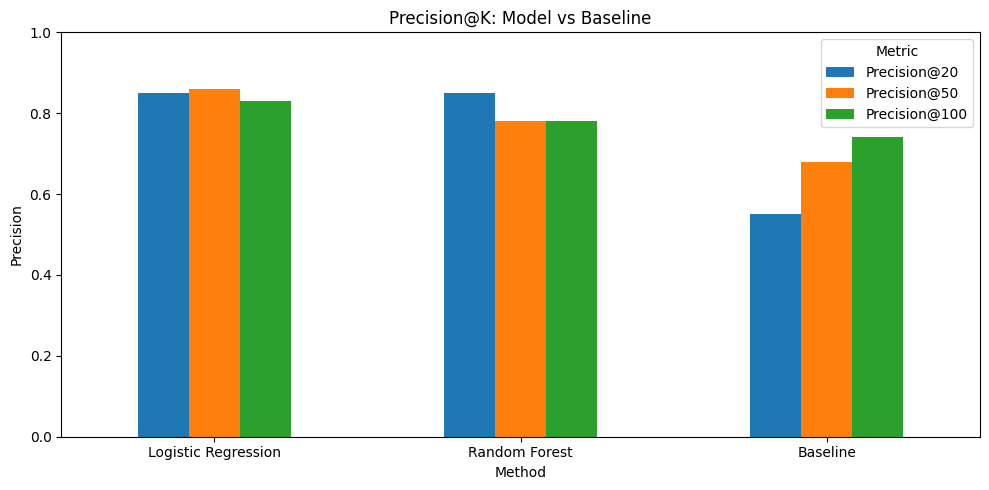

In [56]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Method")[
    ["Precision@20", "Precision@50", "Precision@100"]
]

plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Precision@K: Model vs Baseline")
plt.xlabel("Method")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 4.4 Results interpretation

Logistic Regression provides the strongest top-K ranking performance among the tested methods.

It achieves Precision@20 of 0.85, Precision@50 of 0.86, and Precision@100 of 0.83. The transparent baseline achieves 0.55, 0.68, and 0.74 respectively.

At the 50-page review capacity, Logistic Regression improves Precision@50 by 0.18 over the baseline. This means that, on the held-out evaluation set, approximately 43 of the top 50 ranked pages were future declines compared with approximately 34 for the baseline.

Random Forest performs between the two methods at the top of the queue, with Precision@50 of 0.78, but does not outperform Logistic Regression. At Precision@100, Random Forest (0.73) is slightly below the baseline (0.74).

The results therefore suggest that the simpler Logistic Regression model provides the most useful prioritization for the tested review capacities. This is observed performance under the chosen validation design, not a guarantee of future decline or evidence that a refresh will cause recovery.

## 5. Limitations

*What this work cannot claim.*

This work is decision-support, not causal inference.

The future-decline label identifies pages whose search impressions decreased by more than 20% during the target 30-day period relative to the preceding 30-day reference period. It does not establish why the decline occurred or whether a content refresh would cause recovery.

Several different processes can resemble a decline, including seasonality, consolidation between related pages, changes in search-result behavior, and ordinary traffic noise.

The analysis also evaluates a defined future window and a client-held-out validation design. Performance may therefore differ for other time periods, clients, or traffic conditions.

The recommendations should be treated as pages to review first, not as automatic instructions to refresh, rewrite, prune, or otherwise change content.

All findings are observational and should be described using terms such as observed, measured, directional, and decision-support.

In [57]:
limitations_summary = {
    "causal_claim": "Not supported",
    "refresh_impact_claim": "Not supported",
    "validation": "Client-held-out",
    "prediction_target": "Future 30-day impression decline",
    "primary_metric": "Precision@50",
    "recommended_use": "Prioritize human review",
}

limitations_summary

{'causal_claim': 'Not supported',
 'refresh_impact_claim': 'Not supported',
 'validation': 'Client-held-out',
 'prediction_target': 'Future 30-day impression decline',
 'primary_metric': 'Precision@50',
 'recommended_use': 'Prioritize human review'}

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The recommendation queue ranks held-out content items by Logistic Regression probability of future decline because Logistic Regression achieved the strongest Precision@20, Precision@50, and Precision@100 in the model comparison.

The ranking is intended for limited review capacity. Higher-ranked pages should be investigated earlier, but the model score is not proof that a page should be changed.

Reason codes use observable historical signals so that a reviewer can understand why a page received a high priority.

In [58]:
# More informative, history-only reason codes.

recommendations["reason_code"] = np.select(
    [
        (recommendations["impressions_90d"] >= 10000) &
        (recommendations["avg_position_90d"] <= 10),

        (recommendations["impressions_90d"] >= 10000) &
        (recommendations["avg_position_90d"] > 10),

        (recommendations["impressions_90d"] >= 1000) &
        (recommendations["ctr_90d"] < 0.5),

        recommendations["avg_position_90d"] > 20,
    ],
    [
        "high_visibility_page",
        "high_demand_position_opportunity",
        "visible_low_ctr_page",
        "deep_position_risk",
    ],
    default="general_future_decline_risk"
)

recommendations["recommended_action"] = np.select(
    [
        recommendations["reason_code"] == "high_visibility_page",
        recommendations["reason_code"] == "high_demand_position_opportunity",
        recommendations["reason_code"] == "visible_low_ctr_page",
        recommendations["reason_code"] == "deep_position_risk",
    ],
    [
        "Review for refresh or protection",
        "Review content and search-position opportunity",
        "Review title/meta and intent match",
        "Review whether the page still merits investment",
    ],
    default="Monitor and review"
)

ranked_queue = recommendations[
    [
        "rank",
        "content_hash_id",
        "model_probability",
        "confidence",
        "reason_code",
        "recommended_action",
        "impressions_90d",
        "avg_position_90d",
        "ctr_90d",
    ]
].copy()

display(ranked_queue.head(20))

,rank,content_hash_id,model_probability,confidence,reason_code,recommended_action,impressions_90d,avg_position_90d,ctr_90d
0,1,content_b51957d7f4abe47e,0.996778,High,high_demand_position_opportunity,Review content and search-position opportunity,219069.0,25.261020,0.054321
1,2,content_436860cd6a71be8a,0.990238,High,high_demand_position_opportunity,Review content and search-position opportunity,19536.0,31.796036,0.092138
2,3,content_c287019e9b7219a0,0.988725,High,visible_low_ctr_page,Review title/meta and intent match,5457.0,26.485237,0.036650
3,4,content_99cc4061cbe916a2,0.987398,High,visible_low_ctr_page,Review title/meta and intent match,7955.0,39.490943,0.050283
4,5,content_82b7569d015a86a2,0.984546,High,visible_low_ctr_page,Review title/meta and intent match,3263.0,34.663697,0.061293
5,6,content_341475bbc3a9fa4e,0.980264,High,high_demand_position_opportunity,Review content and search-position opportunity,41969.0,20.485407,0.045272
6,7,content_963de14b1f58978f,0.977832,High,high_visibility_page,Review for refresh or protection,389111.0,5.319145,0.310708
7,8,content_d266146f0dcb4778,0.977408,High,visible_low_ctr_page,Review title/meta and intent match,8604.0,20.226133,0.104603
8,9,content_8a38c9c9ed8038a5,0.974633,High,high_demand_position_opportunity,Review content and search-position opportunity,10441.0,13.239773,0.373527
9,10,content_f6b448b66693938c,0.964732,High,visible_low_ctr_page,Review title/meta and intent match,1690.0,32.589739,0.059172


In [59]:
recommendation_summary = (
    ranked_queue.head(20)
    .groupby(
        ["confidence", "reason_code"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

recommendation_summary

,confidence,reason_code,count
0,High,high_demand_position_opportunity,9
2,High,visible_low_ctr_page,8
1,High,high_visibility_page,3


In [60]:
from pathlib import Path

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

final_queue_path = output_dir / "capstone_ranked_recommendations.csv"

ranked_queue.to_csv(
    final_queue_path,
    index=False
)

print("Saved:", final_queue_path)

Saved: work/outputs/capstone_ranked_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### 7.1 Model comparison

The table below compares the transparent baseline with the learned models on the same client-held-out test set.

Precision@20, Precision@50, and Precision@100 are used because the practical decision is to prioritize a limited review queue.

In [61]:
paper_results = results_df.copy()

display(paper_results.round(4))

,Method,Precision@20,Precision@50,Precision@100,Average Precision
0,Logistic Regression,0.85,0.86,0.83,0.6285
1,Random Forest,0.85,0.78,0.78,0.7032
2,Baseline,0.55,0.68,0.74,0.6387


### 7.2 Precision@K

The chart compares ranking precision at three review capacities. Logistic Regression provides the strongest top-K performance in the evaluated client-held-out sample.

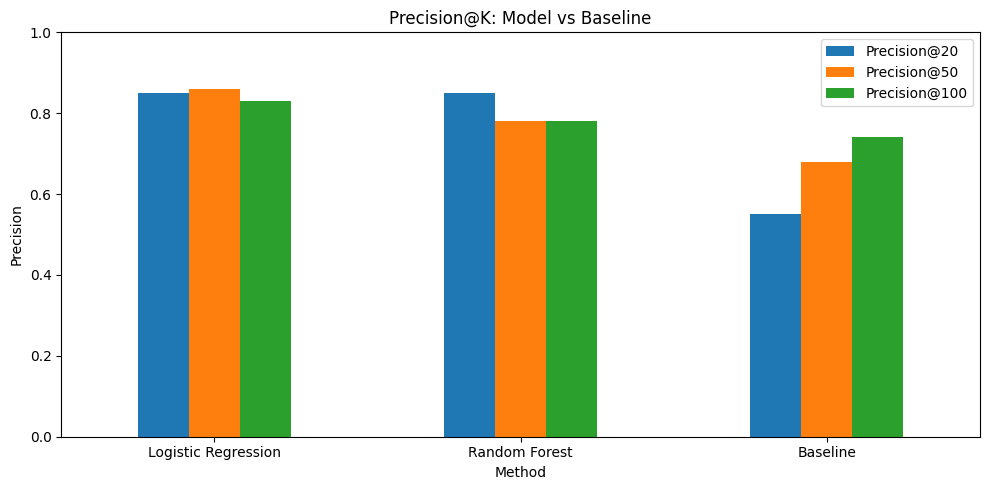

Saved: work/outputs/precision_at_k.png


In [62]:
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

precision_plot = results_df.set_index("Method")[
    ["Precision@20", "Precision@50", "Precision@100"]
]

ax = precision_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Precision@K: Model vs Baseline")
ax.set_xlabel("Method")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()

precision_chart_path = output_dir / "precision_at_k.png"

plt.savefig(
    precision_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", precision_chart_path)

## Feature interpretation

The Logistic Regression coefficients provide an interpretable view of which standardized historical features were most strongly associated with the future-decline label in the validation sample.

The largest coefficient magnitudes were associated with sessions_90d and pageviews_90d, followed by scroll activity, search activity consistency, and click/CTR variables.

These coefficients describe associations learned by the model. They are not causal effects and should not be interpreted as saying that increasing or decreasing a specific metric would cause future decline.

In [63]:
logistic_classifier = logistic_model.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": logistic_classifier.coef_[0]
})

importance_df["absolute_coefficient"] = (
    importance_df["coefficient"].abs()
)

importance_df = (
    importance_df
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(10))

,feature,coefficient,absolute_coefficient
0,pageviews_90d,-2.441252,2.441252
1,sessions_90d,1.954408,1.954408
2,scroll_events_90d,0.414609,0.414609
3,log_clicks_90d,-0.287263,0.287263
4,search_day_rate,0.212399,0.212399
5,active_search_days,0.212399,0.212399
6,ctr_90d,-0.199110,0.199110
7,engaged_sessions_90d,-0.098106,0.098106
8,clicks_90d,-0.071998,0.071998
9,impressions_90d,0.069516,0.069516


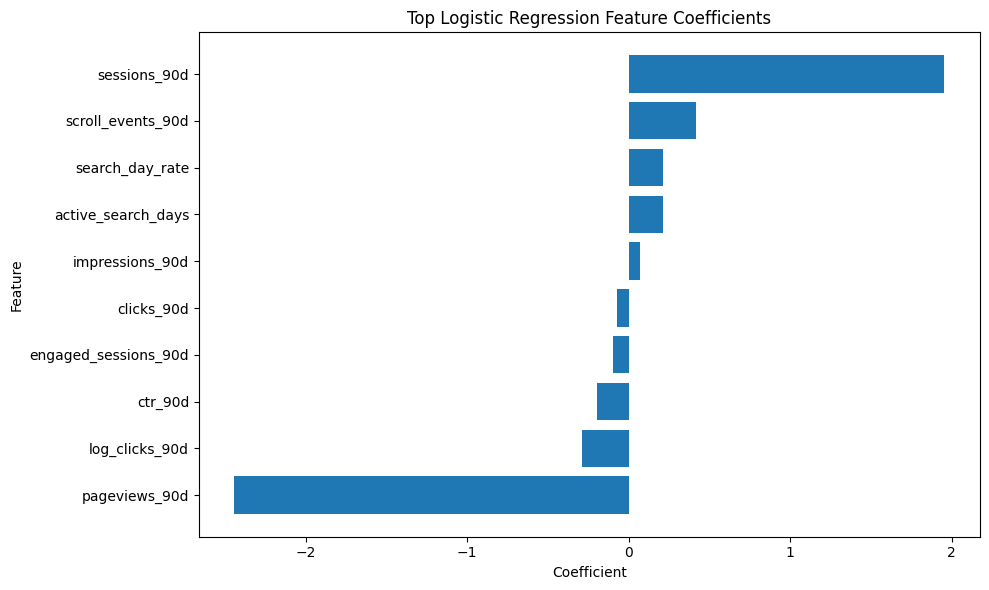

Saved: work/outputs/logistic_feature_coefficients.png


In [64]:
importance_plot = (
    importance_df
    .head(10)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_plot["feature"],
    importance_plot["coefficient"]
)

plt.title("Top Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

feature_chart_path = output_dir / "logistic_feature_coefficients.png"

plt.savefig(
    feature_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", feature_chart_path)

### 7.4 Top-20 recommendation table

The table below contains the highest-ranked review candidates from the Logistic Regression model.

The queue is intended to prioritize human investigation. A high model probability does not guarantee that a page is declining for a particular causal reason or that a refresh is the correct intervention.

In [65]:
paper_top20 = ranked_queue.head(20).copy()

display(paper_top20)

,rank,content_hash_id,model_probability,confidence,reason_code,recommended_action,impressions_90d,avg_position_90d,ctr_90d
0,1,content_b51957d7f4abe47e,0.996778,High,high_demand_position_opportunity,Review content and search-position opportunity,219069.0,25.261020,0.054321
1,2,content_436860cd6a71be8a,0.990238,High,high_demand_position_opportunity,Review content and search-position opportunity,19536.0,31.796036,0.092138
2,3,content_c287019e9b7219a0,0.988725,High,visible_low_ctr_page,Review title/meta and intent match,5457.0,26.485237,0.036650
3,4,content_99cc4061cbe916a2,0.987398,High,visible_low_ctr_page,Review title/meta and intent match,7955.0,39.490943,0.050283
4,5,content_82b7569d015a86a2,0.984546,High,visible_low_ctr_page,Review title/meta and intent match,3263.0,34.663697,0.061293
5,6,content_341475bbc3a9fa4e,0.980264,High,high_demand_position_opportunity,Review content and search-position opportunity,41969.0,20.485407,0.045272
6,7,content_963de14b1f58978f,0.977832,High,high_visibility_page,Review for refresh or protection,389111.0,5.319145,0.310708
7,8,content_d266146f0dcb4778,0.977408,High,visible_low_ctr_page,Review title/meta and intent match,8604.0,20.226133,0.104603
8,9,content_8a38c9c9ed8038a5,0.974633,High,high_demand_position_opportunity,Review content and search-position opportunity,10441.0,13.239773,0.373527
9,10,content_f6b448b66693938c,0.964732,High,visible_low_ctr_page,Review title/meta and intent match,1690.0,32.589739,0.059172


### 7.5 Recommendation summary

The top-ranked queue is summarized by confidence and reason code so that the paper can describe the types of opportunities identified without exposing unnecessary row-level detail.

In [66]:
recommendation_summary = (
    ranked_queue.head(20)
    .groupby(
        ["confidence", "reason_code"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(recommendation_summary)

,confidence,reason_code,count
0,High,high_demand_position_opportunity,9
2,High,visible_low_ctr_page,8
1,High,high_visibility_page,3


In [67]:
final_queue_path = output_dir / "capstone_ranked_recommendations.csv"

ranked_queue.to_csv(
    final_queue_path,
    index=False
)

print("Saved:", final_queue_path)

Saved: work/outputs/capstone_ranked_recommendations.csv


# ML-12 Closing Deliverables

## 5-minute demo outline

### 0:00–0:45 — Problem
I wanted to answer whether historical search-performance signals could identify content pages likely to experience a meaningful search-impression decline in the following 30 days.

### 0:45–1:30 — Data and design
I used the pseudonymized FlyRank warehouse and constructed a forward-looking setup where historical signals precede the target window. The model predicts future decline rather than using the current-window `trend_direction` proxy.

### 1:30–2:30 — Method
I created a transparent baseline and compared Logistic Regression and Random Forest using client-held-out validation. The main evaluation metric was Precision@50 because the project is designed around prioritizing a review queue.

### 2:30–3:30 — Results
Logistic Regression achieved Precision@20 of 0.85, Precision@50 of 0.86, and Precision@100 of 0.83. The baseline achieved 0.55, 0.68, and 0.74 respectively.

### 3:30–4:15 — Interpretation
The learned model produced a stronger top-ranked queue than the baseline under this validation design. Random Forest did not outperform Logistic Regression at the tested review capacities, showing that greater complexity did not automatically produce better prioritization.

### 4:15–5:00 — Recommendations and limitations
The final output is a ranked review queue with reason codes and suggested actions. These are decision-support recommendations: they identify pages worth human investigation but do not prove causality or guarantee that refreshing a page will improve performance.

## Social-post cut

Built a forward-looking content-decline prioritization model on pseudonymized FlyRank search data.

Using a client-held-out evaluation, Logistic Regression reached 0.86 Precision@50 versus 0.68 for the transparent baseline, putting roughly 43 future-declining pages in the top 50 versus about 34 for the baseline.

The result is decision-support, not causal proof: the model helps prioritize which pages deserve human review first.

## Employer-facing summary

I built a leakage-aware search-intelligence pipeline that used historical content and search signals to rank pages likely to experience future search-impression decline. Logistic Regression achieved 0.86 Precision@50 on a client-held-out evaluation, outperforming the transparent baseline at the main review-queue cutoffs. The project demonstrates end-to-end skills in DuckDB data engineering, feature construction, validation, model comparison, ranking evaluation, and translating model output into explainable decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
